<a href="https://colab.research.google.com/github/wahiwatkar06-gif/mdm-practicals/blob/main/Practical_no_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/retail_sales_dataset (2) (1).csv')
display(df.head())

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [ ]:

df.dtypes

,0
Transaction ID,int64
Date,object
Customer ID,object
Gender,object
Age,int64
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [ ]:
duplicate = df.duplicated().sum()

if duplicate > 0:
  df.drop_duplicates(inplace=True)
  print(f"Dropped {duplicate} duplicate rows.")

In [ ]:
#MISSING VALUES HANDLING
num_missing_values = df.isnull().sum().sum()

if num_missing_values > 0:
  df.dropna(inplace=True)
  print(f"Dropped {num_missing_values} missing values by removing corresponding rows.")
else:
  print("No missing values found.")

No missing values found.


In [ ]:
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


**Univariate analysis**

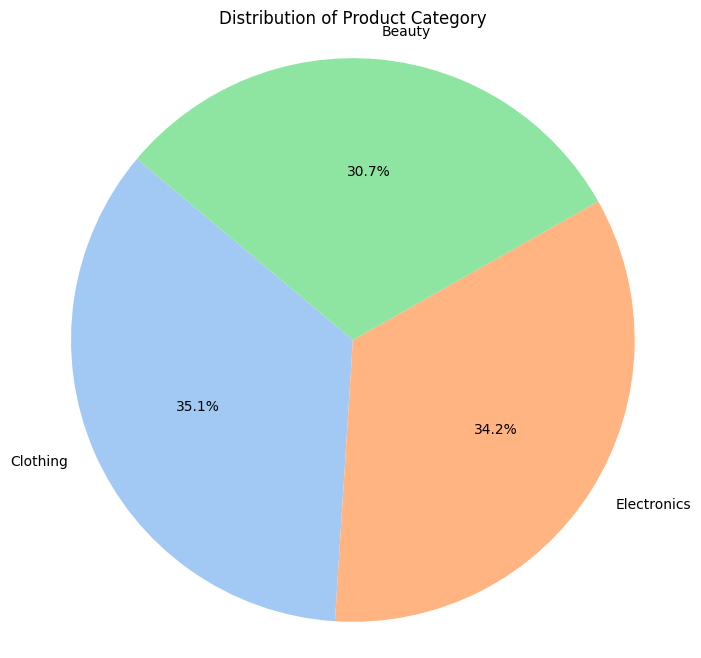

In [ ]:
category_counts = df['Product Category'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Product Category')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

/tmp/ipykernel_1510/436945897.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='viridis')


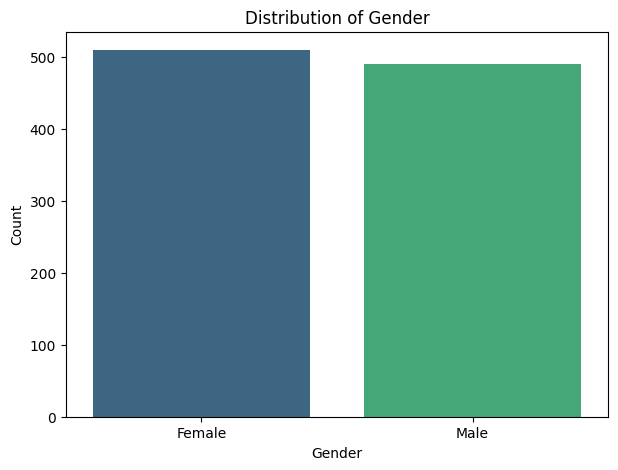

In [ ]:
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='viridis')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

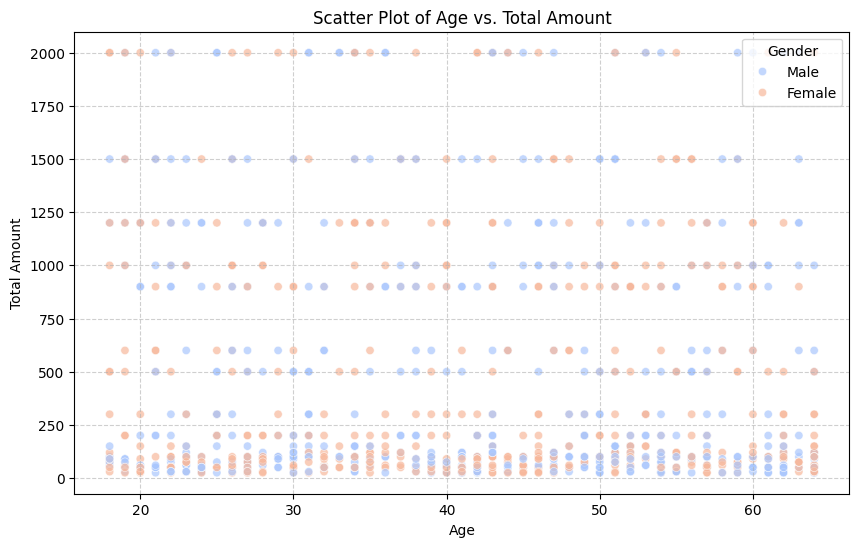

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Total Amount', data=df, hue='Gender', palette='coolwarm', alpha=0.7)
plt.title('Scatter Plot of Age vs. Total Amount')
plt.xlabel('Age')
plt.ylabel('Total Amount')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Total Sales by Product Category**

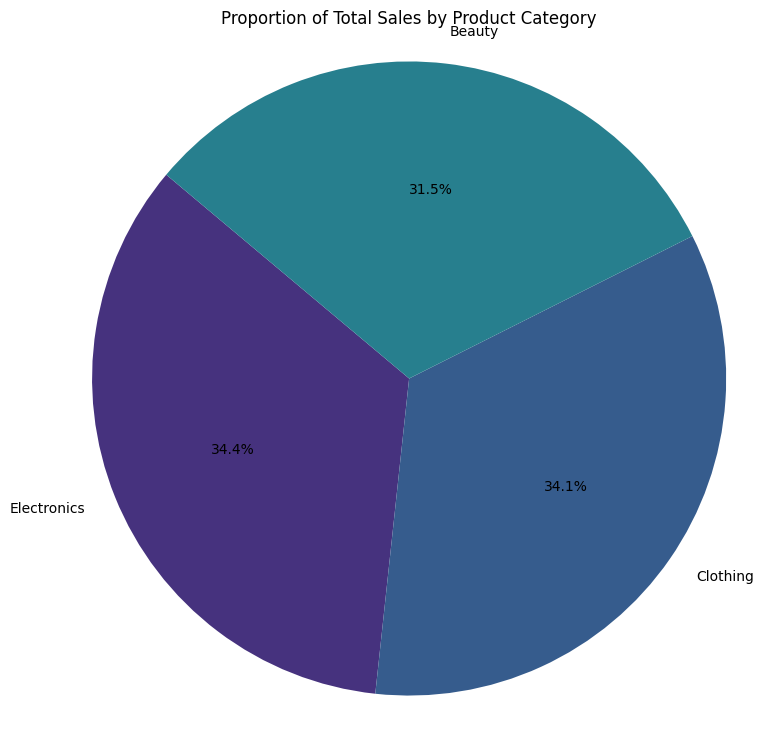

In [ ]:
category_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 9))
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis'))
plt.title('Proportion of Total Sales by Product Category')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

/tmp/ipykernel_1510/324487090.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette='magma')


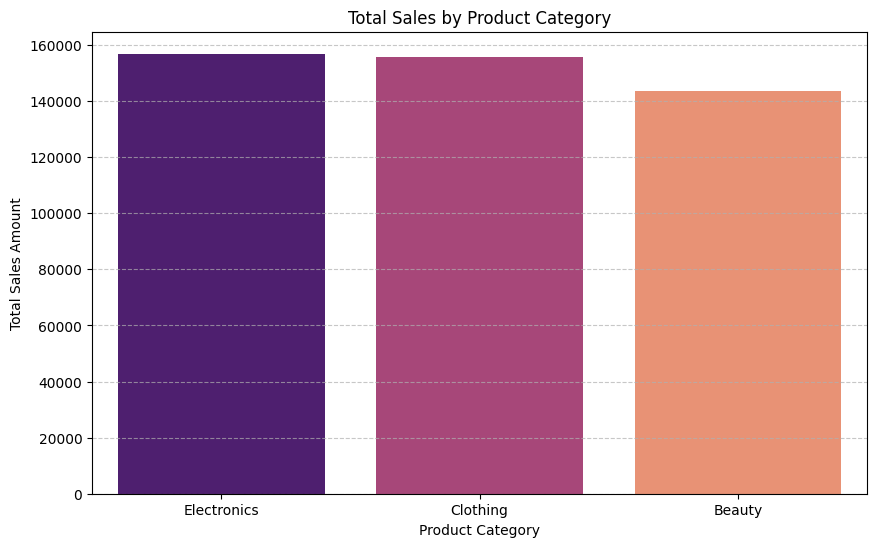

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=category_sales.index, y=category_sales.values, palette='magma')
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Numerical Analysis of Total Amount**

**NUMERICAL**

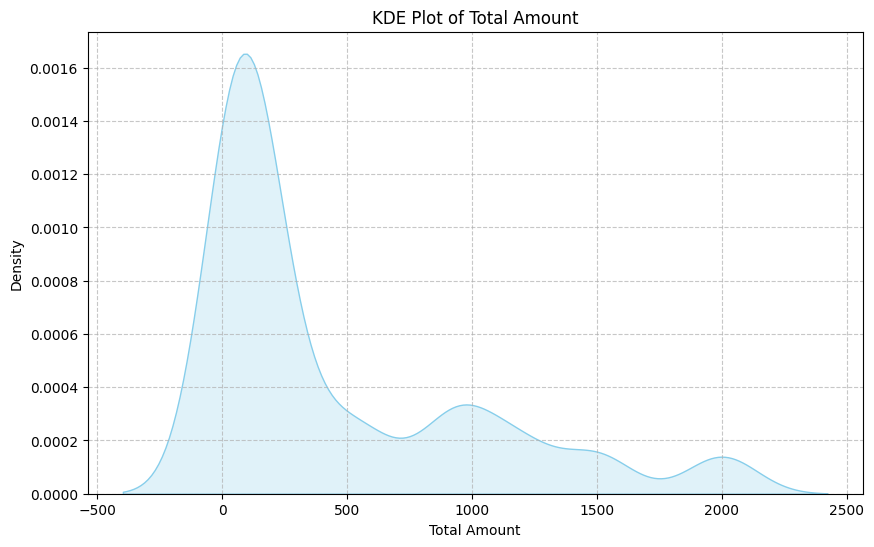

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df['Total Amount'], fill=True, color='skyblue')
plt.title('KDE Plot of Total Amount')
plt.xlabel('Total Amount')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The Kernel Density Estimate (KDE) plot shows the probability density function of the 'Total Amount', providing a smooth representation of its distribution.

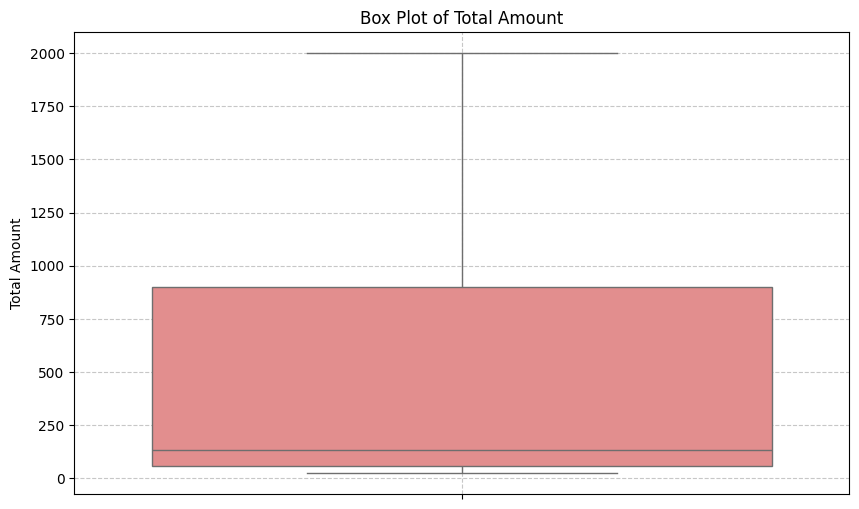

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Total Amount'], color='lightcoral')
plt.title('Box Plot of Total Amount')
plt.ylabel('Total Amount')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

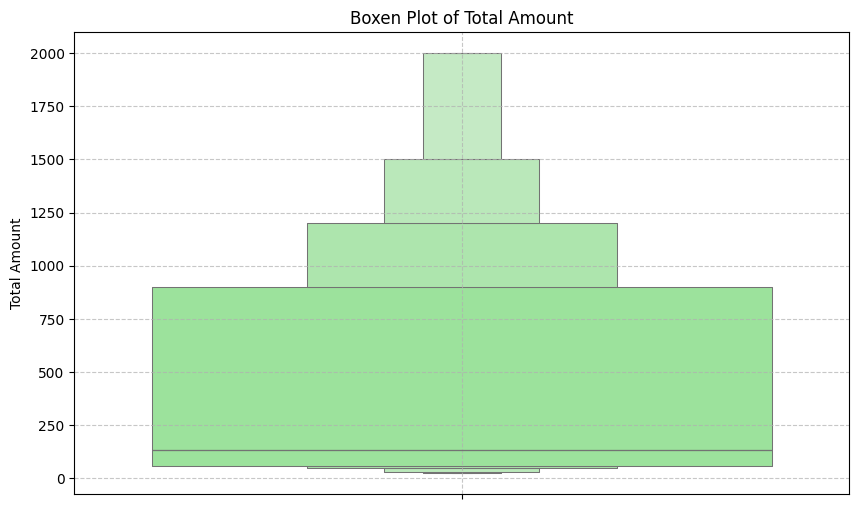

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxenplot(y=df['Total Amount'], color='lightgreen')
plt.title('Boxen Plot of Total Amount')
plt.ylabel('Total Amount')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

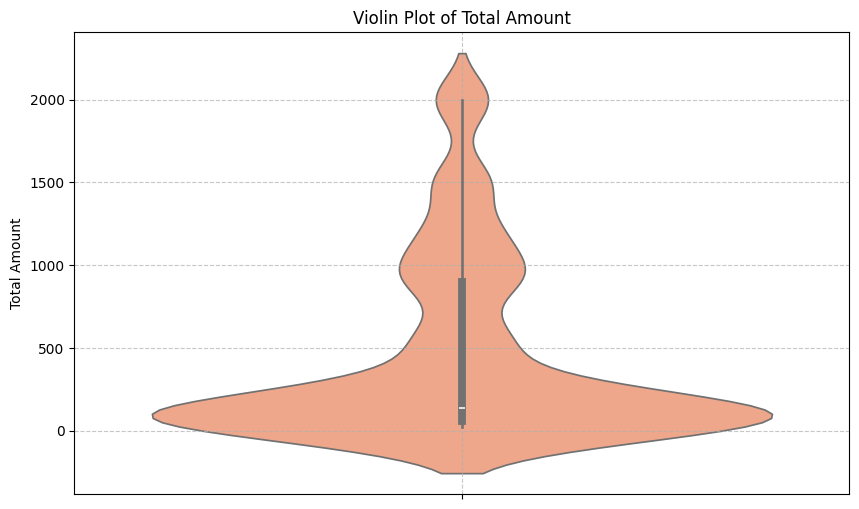

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(y=df['Total Amount'], color='lightsalmon')
plt.title('Violin Plot of Total Amount')
plt.ylabel('Total Amount')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

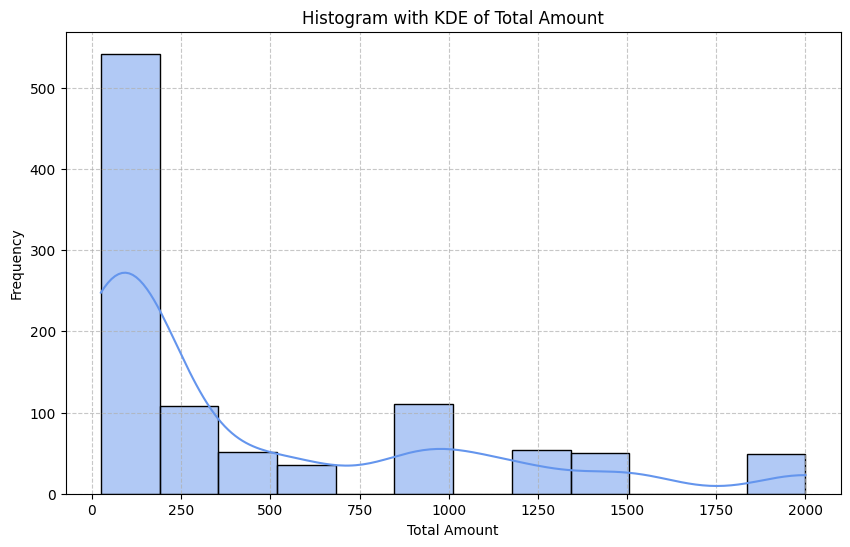

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Total Amount'], kde=True, color='cornflowerblue')
plt.title('Histogram with KDE of Total Amount')
plt.xlabel('Total Amount')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Distribution Plot for Age**

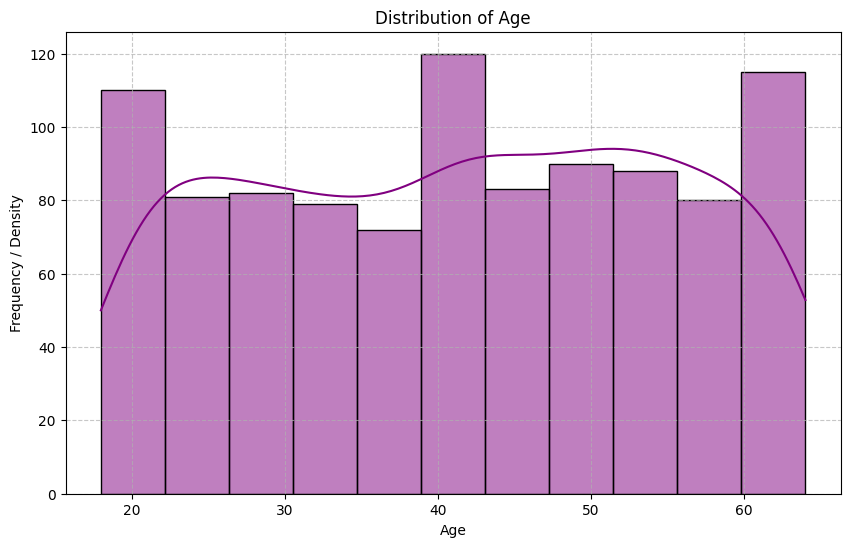

In [ ]:

plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, color='purple')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency / Density')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**BIVARIATE ANALYSIS**

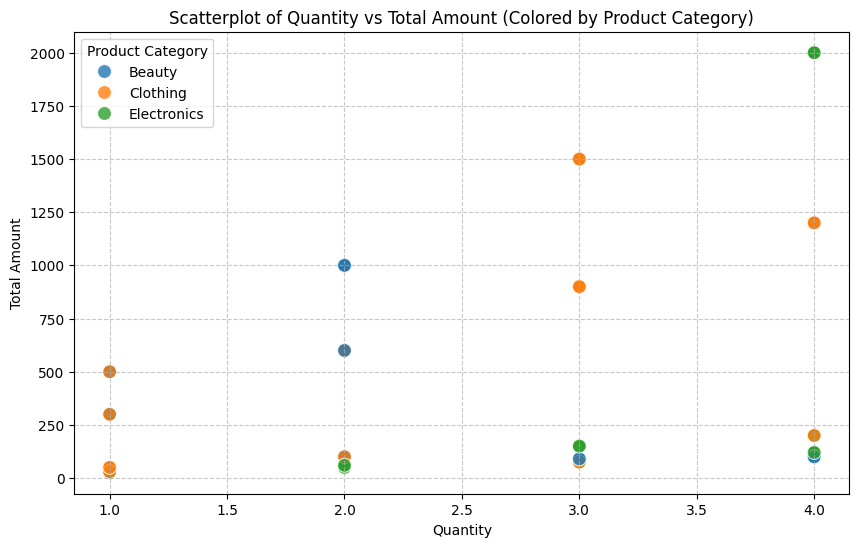

In [ ]:

# Scatterplot: Quantity vs Total Amount
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Quantity', y='Total Amount', data=df, hue='Product Category', palette='tab10', s=100, alpha=0.8)
plt.title('Scatterplot of Quantity vs Total Amount (Colored by Product Category)')
plt.xlabel('Quantity')
plt.ylabel('Total Amount')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

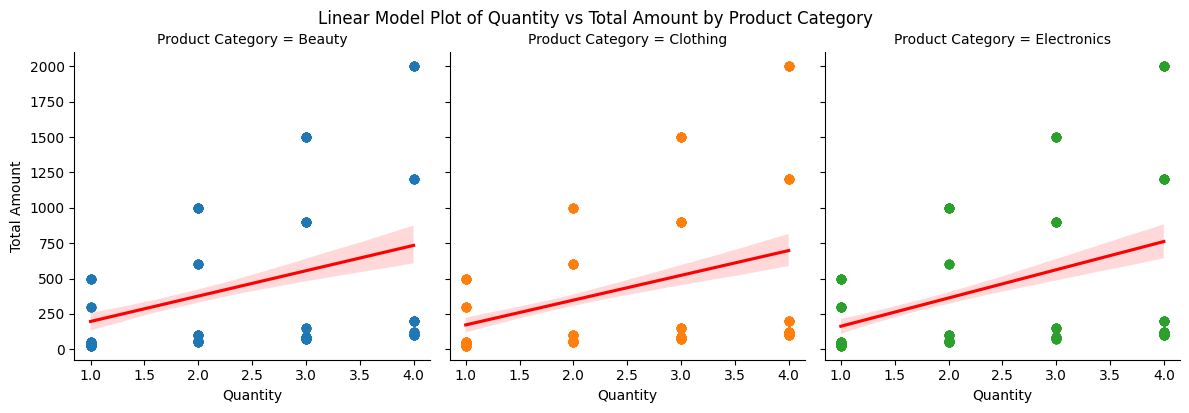

In [ ]:
# lmplot: Quantity vs Total Amount (with linear model fit)
sns.lmplot(x='Quantity', y='Total Amount', data=df, hue='Product Category', col='Product Category', col_wrap=3, height=4, scatter_kws={'alpha':0.6}, line_kws={'color': 'red'})
plt.suptitle('Linear Model Plot of Quantity vs Total Amount by Product Category', y=1.02) # Adjust suptitle position
plt.show()

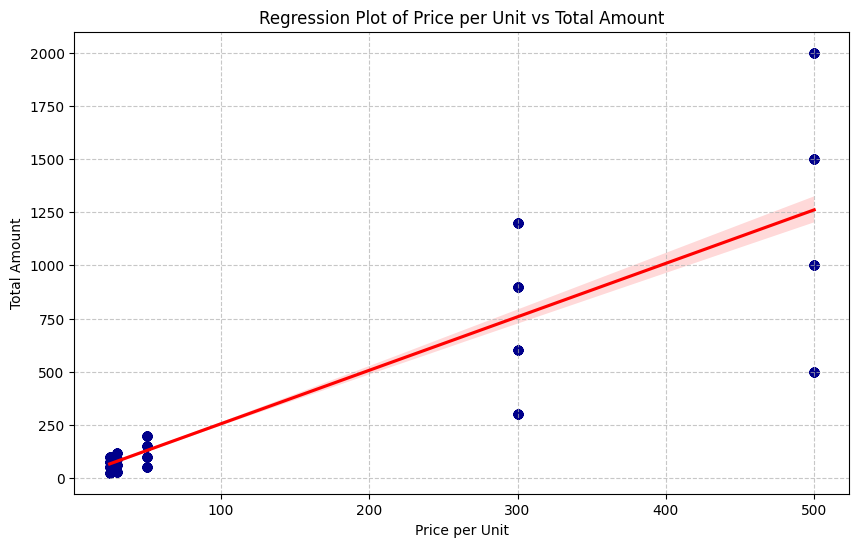

In [ ]:
# Regplot: Price per Unit vs Total Amount
plt.figure(figsize=(10, 6))
sns.regplot(x='Price per Unit', y='Total Amount', data=df, scatter_kws={'alpha':0.6, 'color':'darkblue'}, line_kws={'color': 'red'})
plt.title('Regression Plot of Price per Unit vs Total Amount')
plt.xlabel('Price per Unit')
plt.ylabel('Total Amount')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

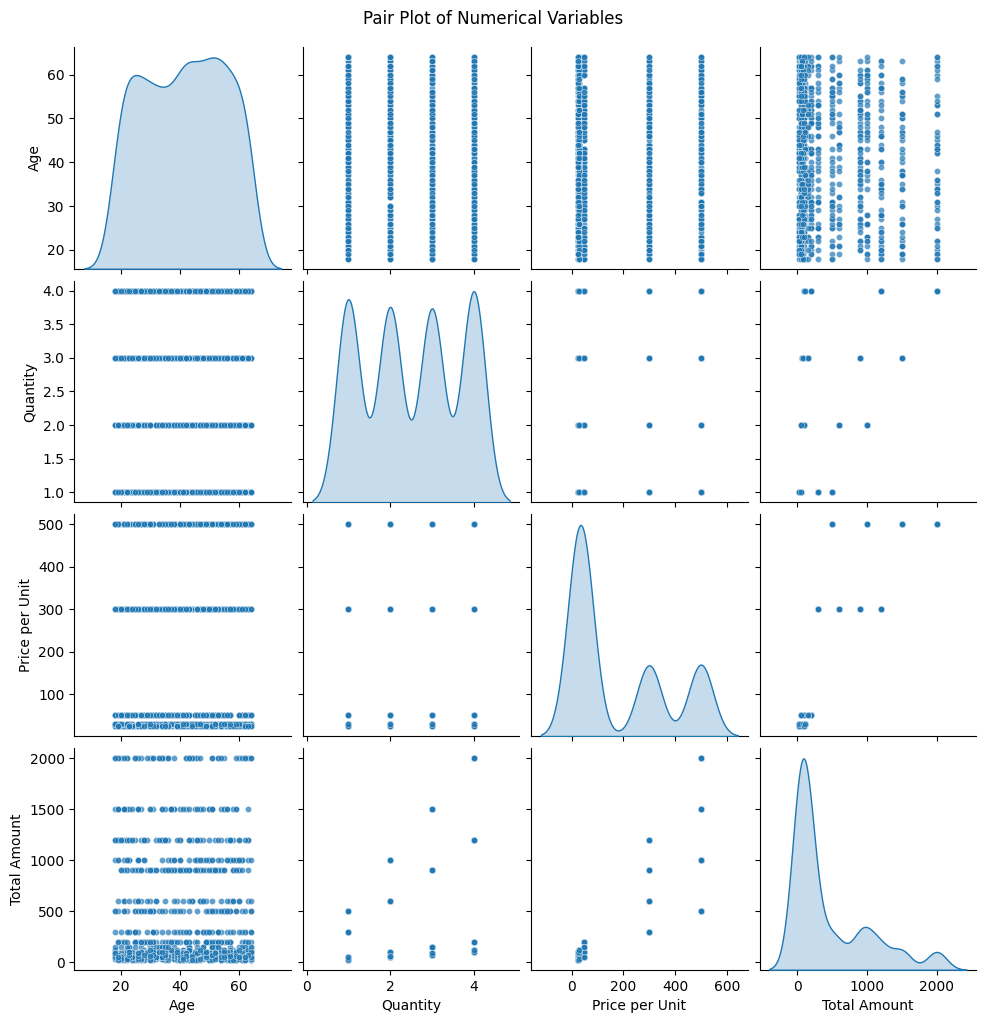

In [ ]:
# Pairplot for selected numerical columns
numerical_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
sns.pairplot(df[numerical_cols], diag_kind='kde', plot_kws={'alpha':0.7, 's':20})
plt.suptitle('Pair Plot of Numerical Variables', y=1.02) # Adjust suptitle position
plt.show()

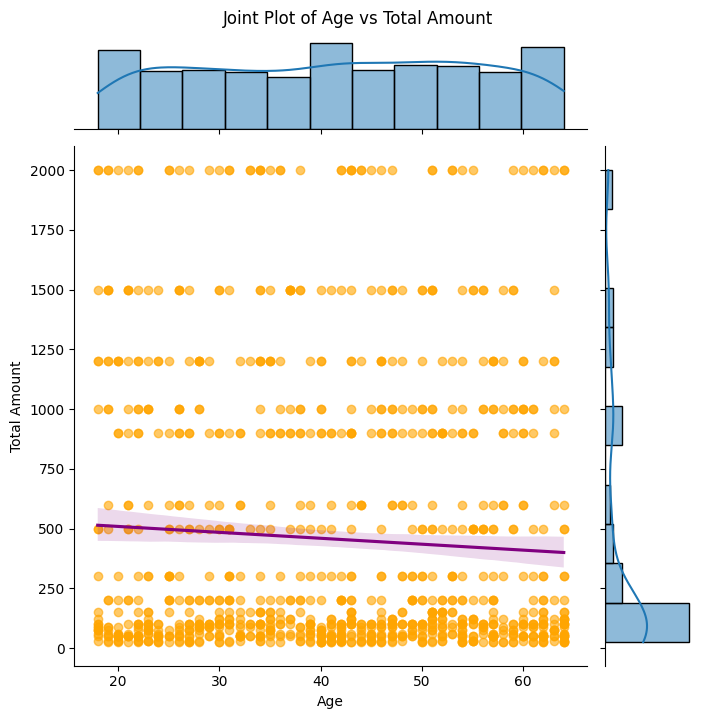

In [ ]:
# Jointplot: Age vs Total Amount
sns.jointplot(x='Age', y='Total Amount', data=df, kind='reg', height=7, scatter_kws={'alpha':0.6, 'color':'orange'}, line_kws={'color': 'purple'})
plt.suptitle('Joint Plot of Age vs Total Amount', y=1.02) # Adjust suptitle position
plt.show()

**Total Sales by Product Category and Gender**

This bar chart illustrates the total sales amount for each product category, with bars grouped by gender. It allows for a direct comparison of sales performance across categories between male and female customers.

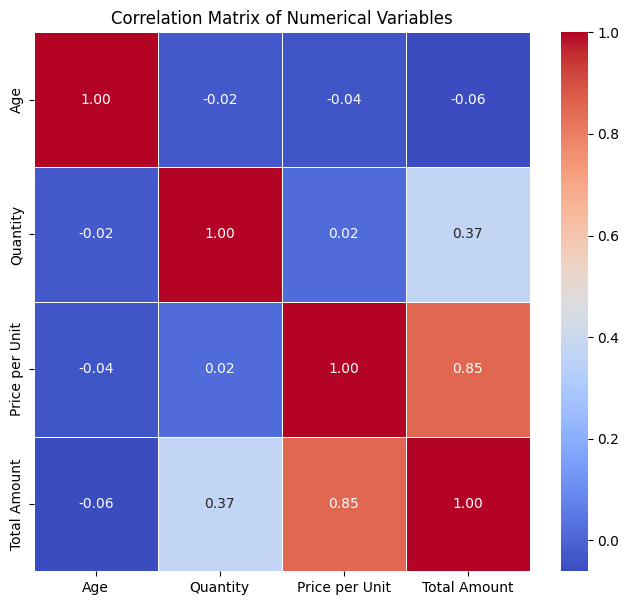

In [ ]:
correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(8, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

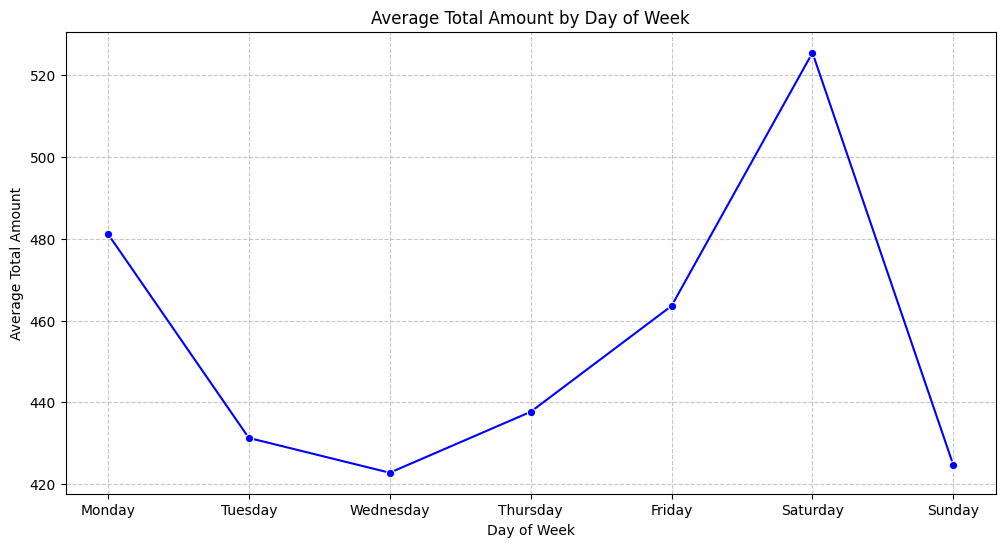

In [ ]:
# Extract day of week from the 'Date' column to resolve the KeyError
df['Day of Week'] = df['Date'].dt.day_name()

average_sales_by_day = df.groupby('Day of Week')['Total Amount'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.figure(figsize=(12, 6))
sns.lineplot(x=average_sales_by_day.index, y=average_sales_by_day.values, marker='o', color='blue')
plt.title('Average Total Amount by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Total Amount')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


**NUMERICAL CATEGORICAL**

/tmp/ipykernel_1510/924545644.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product Category', y='Total Amount', data=df, palette='Spectral')


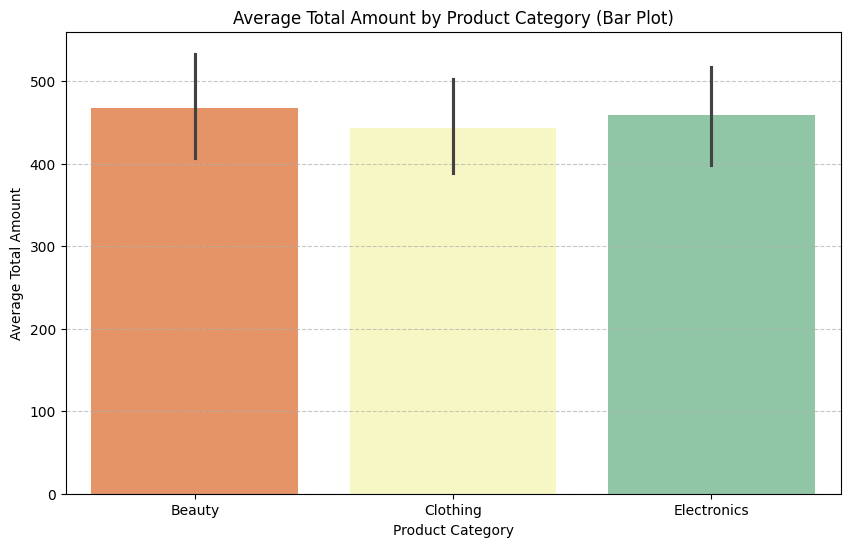

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Product Category', y='Total Amount', data=df, palette='Spectral')
plt.title('Average Total Amount by Product Category (Bar Plot)')
plt.xlabel('Product Category')
plt.ylabel('Average Total Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_1510/3738722895.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product Category', y='Total Amount', data=df, palette='pastel')


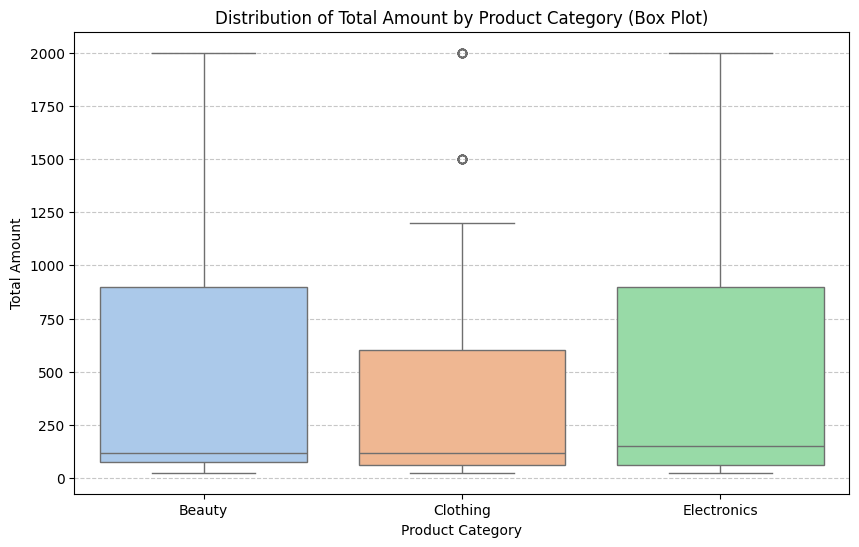

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Product Category', y='Total Amount', data=df, palette='pastel')
plt.title('Distribution of Total Amount by Product Category (Box Plot)')
plt.xlabel('Product Category')
plt.ylabel('Total Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_1510/781942199.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Product Category', y='Total Amount', data=df, palette='viridis')


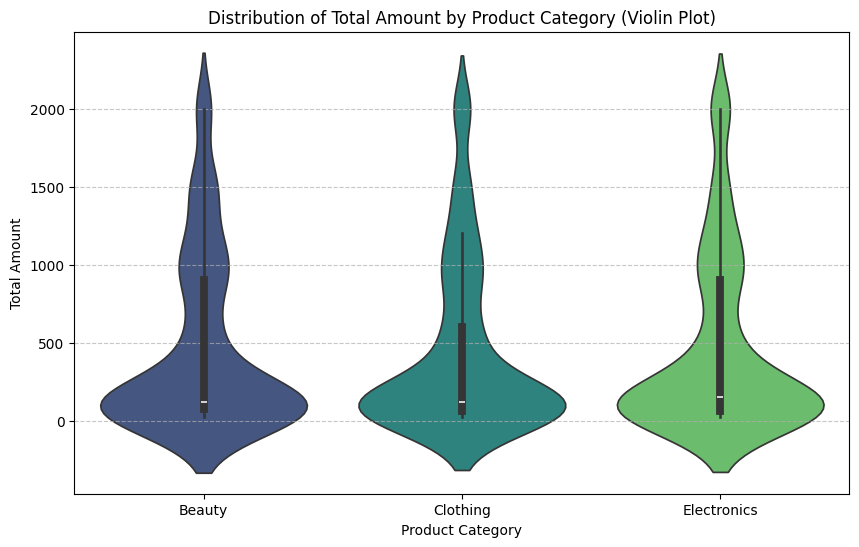

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Product Category', y='Total Amount', data=df, palette='viridis')
plt.title('Distribution of Total Amount by Product Category (Violin Plot)')
plt.xlabel('Product Category')
plt.ylabel('Total Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_1510/809329383.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Product Category', y='Total Amount', data=df, jitter=True, palette='plasma', alpha=0.7)


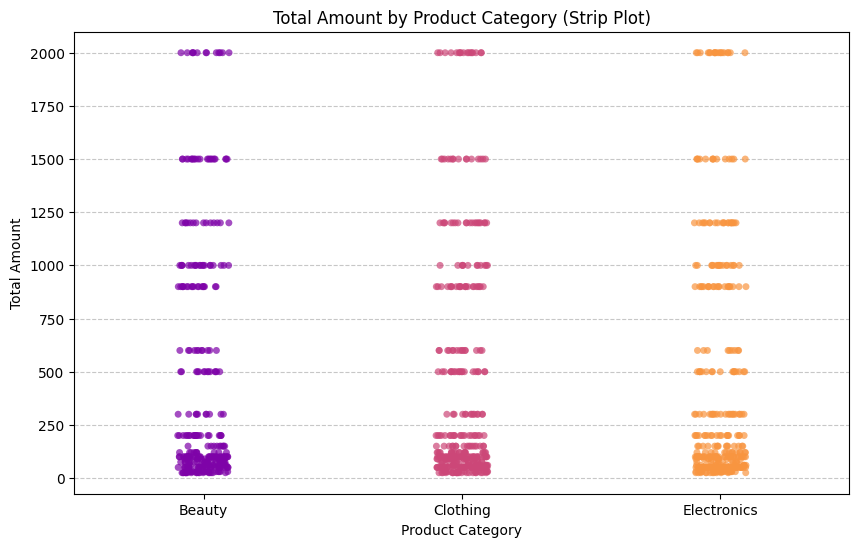

In [ ]:
plt.figure(figsize=(10, 6))
sns.stripplot(x='Product Category', y='Total Amount', data=df, jitter=True, palette='plasma', alpha=0.7)
plt.title('Total Amount by Product Category (Strip Plot)')
plt.xlabel('Product Category')
plt.ylabel('Total Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_1510/3360215499.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Product Category', y='Total Amount', data=df, palette='magma')
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 17.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 18.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 17.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-pack

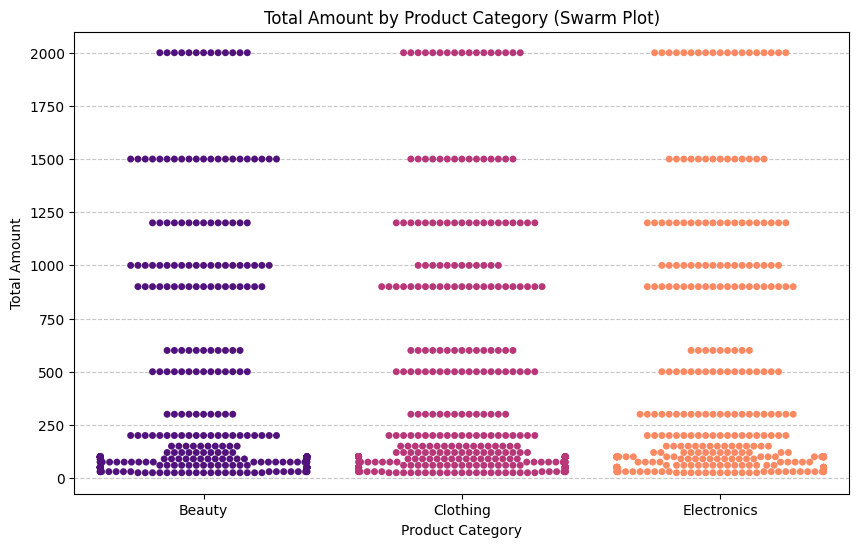

In [ ]:
plt.figure(figsize=(10, 6))
sns.swarmplot(x='Product Category', y='Total Amount', data=df, palette='magma')
plt.title('Total Amount by Product Category (Swarm Plot)')
plt.xlabel('Product Category')
plt.ylabel('Total Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


**CATEGORICAI**


SIDE BY SIDE GRAPH

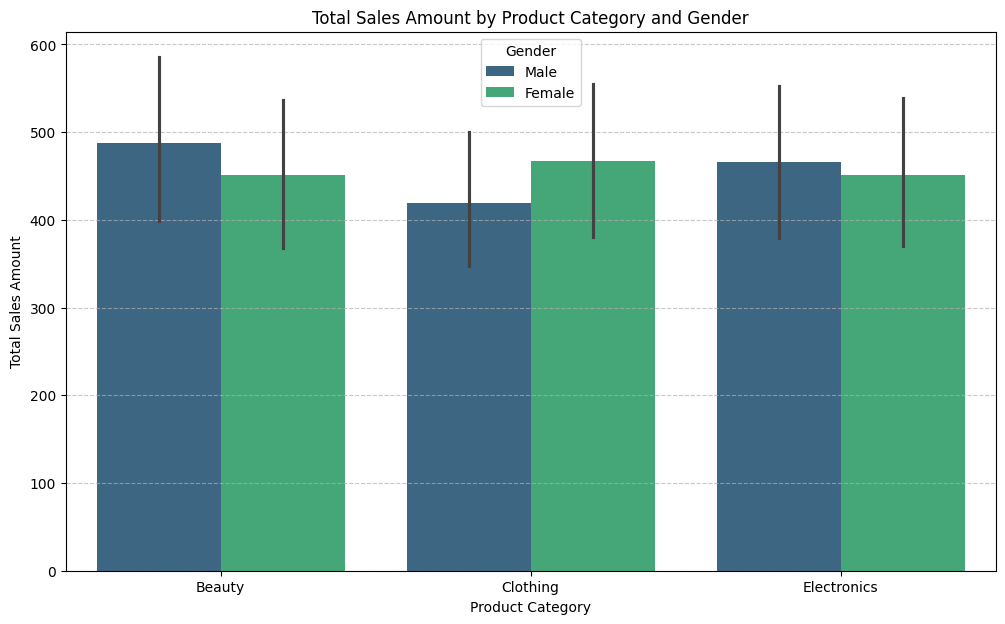

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Product Category', y='Total Amount', hue='Gender', data=df, palette='viridis')
plt.title('Total Sales Amount by Product Category and Gender')
plt.xlabel('Product Category')
plt.ylabel('Total Sales Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Gender')
plt.show()

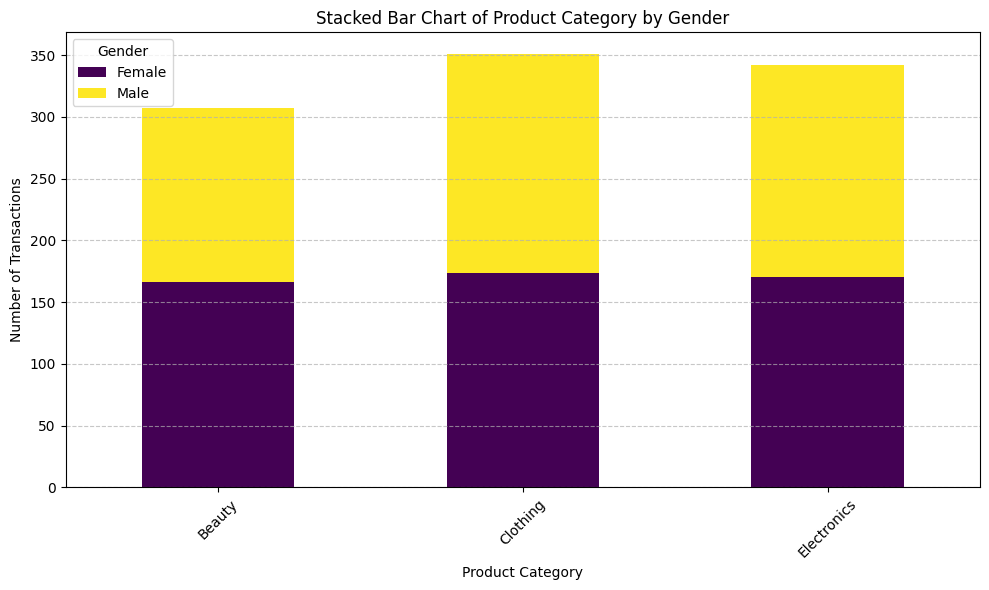

In [ ]:
# Create a cross-tabulation of Product Category and Gender
crosstab_df = pd.crosstab(df['Product Category'], df['Gender'])

# Plotting the stacked bar chart
crosstab_df.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Stacked Bar Chart of Product Category by Gender')
plt.xlabel('Product Category')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Feature Engineering: Adding 'Profit Margin'**

In [ ]:

df['Profit Margin'] = df['Total Amount'] / df['Quantity']
display(df.head())

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Day of Week,Profit Margin
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,Friday,50.0
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,Monday,500.0
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,Friday,30.0
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,Sunday,500.0
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,Saturday,50.0



**Feature Engineering: Adding Time-Based Features**

In [ ]:
df['Day of Week'] = df['Date'].dt.day_name()
df['Month'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year
df['Is Weekend'] = df['Date'].dt.dayofweek >= 5 # Saturday (5) or Sunday (6)
display(df.head())

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Day of Week,Profit Margin,Month,Year,Is Weekend
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,Friday,50.0,November,2023,False
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,Monday,500.0,February,2023,False
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,Friday,30.0,January,2023,False
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,Sunday,500.0,May,2023,True
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,Saturday,50.0,May,2023,True
